In [1]:
!pip install openai rdflib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 8.4 MB/s eta 0:00:00


In [11]:
!apt-get install -y fonts-nanum -q
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
print("폰트 설치 완료")

Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (6,992 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
폰트 설치 완료


# 셀 2: 환경 설정 및 텍스트 소스

In [3]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(api_key=userdata.get('ontology'))
MODEL = "gpt-4o"

DOMAIN_TEXT = """
도금욕 공정 개요:
도금액이 도금조 내에 들어있는 상태의 경우를 의미하는 것으로, 실제 도금이 진행되는 작업이다.
전기도금은 외부 직류 전원으로부터 외부 전기회로인 금속도체를 통하여 전자가 외부 전기회로로
흘러나오고, 용액 중 전기 이동기구는 이온으로, 전위가 인가되면 양이온은 음극으로 이동하고
음이온은 양극으로 이동하게 된다. 전해질 내에 금속이온이 음극으로 이동하여 환원반응을 통해
금속으로 석출되는 과정이 이루어진다.

이슈사항(Pain point):
도금욕 공정의 경우, 용액의 pH 농도에 따라 도금 품질에 영향을 미쳐 품질 불량이 이루어질 수 있는데,
적정 범위를 벗어날 경우 내구성, 부착성, 내흑변성, 내백청성, 방청성 등의 보호 특성이 저하되거나
에칭이 발생하고 체형 안정성이 떨어질 수 있다.
전류 밀도가 너무 낮으면 도금 효율이 낮아지고 공정 시간이 상당히 지연될 수 있으며, 반대의 경우
밀착력이 감소하거나 버닝 등으로 인한 표면 얼룩 발생으로 품질이 저하되는 문제가 있다.
전압 역시 도금조의 pH 상태에 따라 적정 전류 밀도를 유지하기 위해 상시 조절되어야 하는 변수이다.
온도 역시 품질에 영향을 주는 주요 변수 중 하나로, 너무 높으면 증발량 과다로 인해서 도금 용액의
농도 및 물성 조절이 어렵고 심한 경우 역으로 부식을 발생시킬 수 있다. 또한, 낮은 경우에도 도금
과정에 필요한 적절한 활성화 에너지가 형성되지 못하므로 도금 효율이 매우 떨어질 수 있다.

데이터 변수 정의:
- pH: 도금욕 설비 내 공정 pH 측정값 (float, 평균 2.29, 범위 1.51~5.48)
- Temp: 도금욕 설비 내 공정 온도 측정값 (float, 평균 24.48, 범위 17.02~27.99)
- Current: 도금욕 설비 내 공정 전류 측정값 (float, 평균 3.73, 범위 1.52~4.49)
- Voltage: 도금욕 설비 내 공정 전압 측정값 (float, 평균 3.98, 범위 1.01~4.99)
- Result: 품질 판정 결과 (0=정상, 1=불량)
"""

print("텍스트 소스 준비 완료")

텍스트 소스 준비 완료


# 셀 3: 데이터 로드

In [4]:
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()  # kemp-abh-sensor.csv 업로드

df = pd.read_csv('kemp-abh-sensor.csv', encoding='cp949')
print(f"데이터 shape: {df.shape}")
print(f"Lot 수: {df['Lot'].nunique()}개")
print(f"불량률: {df['Result'].mean()*100:.2f}%")

# Lot별 현황
lot_summary = df.groupby('Lot').agg(
    total=('Result', 'count'),
    defects=('Result', 'sum'),
    defect_rate=('Result', 'mean'),
    pH_mean=('pH', 'mean'),
    pH_std=('pH', 'std'),
    Temp_mean=('Temp', 'mean'),
    Temp_std=('Temp', 'std'),
    Current_mean=('Current', 'mean'),
    Current_std=('Current', 'std'),
    Voltage_mean=('Voltage', 'mean'),
    Voltage_std=('Voltage', 'std')
).round(3)

print("\nLot별 요약:")
print(lot_summary)

Saving kemp-abh-sensor.csv to kemp-abh-sensor.csv
데이터 shape: (47058, 9)
Lot 수: 22개
불량률: 1.76%

Lot별 요약:
     total  defects  defect_rate  pH_mean  pH_std  Temp_mean  Temp_std  \
Lot                                                                      
1     2139        0        0.000    2.292   0.476     24.447     1.894   
2     2139       69        0.032    2.279   0.495     24.471     1.911   
3     2139      138        0.065    2.302   0.535     24.531     1.915   
4     2139        0        0.000    2.285   0.493     24.466     1.888   
5     2139        0        0.000    2.284   0.499     24.519     1.904   
6     2139        0        0.000    2.291   0.508     24.439     1.906   
7     2139        0        0.000    2.288   0.485     24.542     1.887   
8     2139      138        0.065    2.275   0.497     24.393     1.905   
9     2139        0        0.000    2.291   0.506     24.543     1.887   
10    2139      138        0.065    2.314   0.512     24.442     1.905   
11    21

# 셀 4: LLM 기반 온톨로지 자동 구축

In [29]:
import json
import re

def parse_json_response(content):
    content = content.replace('```json', '').replace('```', '').strip()
    json_match = re.search(r'\{.*\}', content, re.DOTALL)
    if json_match:
        return json.loads(json_match.group())
    raise ValueError(f"JSON 파싱 실패:\n{content}")

def build_ontology(domain_text):
    """Kommineni et al.(2024) 방법론: 텍스트 → 온톨로지 자동 구축"""

    # Step 1: CQ 생성
    print("Step 1: Competency Questions 자동 생성 중...")
    cq_response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "system",
                "content": "당신은 제조 도메인 온톨로지 엔지니어입니다. 반드시 JSON 형식으로만 응답하세요."
            },
            {
                "role": "user",
                "content": f"""다음 도금욕 공정 문서를 읽고,
AI가 Lot별 품질 이상을 분석하고 설명하기 위해 온톨로지가 반드시 답할 수 있어야 하는
핵심 질문 10개를 생성하세요.

문서:
{domain_text}

응답 형식:
{{"competency_questions": ["질문1", "질문2", ...]}}"""
            }
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    cqs = parse_json_response(cq_response.choices[0].message.content)
    cqs = cqs['competency_questions']
    print(f"  → {len(cqs)}개 CQ 생성 완료")

    # Step 2: TBox 자동 설계
    print("Step 2: TBox 자동 설계 중...")
    cq_text = "\n".join([f"- {cq}" for cq in cqs])

    tbox_response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "system",
                "content": "당신은 제조 도메인 온톨로지 엔지니어입니다. 반드시 JSON 형식으로만 응답하세요."
            },
            {
                "role": "user",
                "content": f"""다음 문서와 Competency Questions를 기반으로
도금욕 공정 온톨로지 TBox를 설계하세요.

문서:
{domain_text}

Competency Questions:
{cq_text}

중요: data_properties의 normal_min, normal_max는
문서의 내용과 데이터 통계를 종합해서 반드시 숫자로 명시하세요.

응답 형식:
{{
    "classes": [
        {{"name": "클래스명", "korean": "한국어명", "description": "설명"}}
    ],
    "object_properties": [
        {{"name": "관계명", "domain": "주어클래스", "range": "목적어클래스"}}
    ],
    "data_properties": [
        {{"name": "변수명", "normal_min": 숫자, "normal_max": 숫자,
          "unit": "단위", "description": "정상범위 벗어날 때 영향"}}
    ],
    "causal_rules": [
        {{"variable": "변수명", "condition": "조건",
          "defect_types": ["불량유형1", "불량유형2"]}}
    ]
}}"""
            }
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )

    tbox = parse_json_response(tbox_response.choices[0].message.content)
    print(f"  → TBox 생성 완료")
    print(f"     클래스: {len(tbox['classes'])}개")
    print(f"     데이터 속성: {len(tbox['data_properties'])}개")
    print(f"     인과 규칙: {len(tbox['causal_rules'])}개")

    return cqs, tbox

cqs, tbox = build_ontology(DOMAIN_TEXT)

print("\n=== 자동 구축된 온톨로지 정상범위 ===")
for prop in tbox['data_properties']:
    print(f"  {prop['name']}: [{prop['normal_min']} ~ {prop['normal_max']}] {prop.get('unit','')}")

print("\n=== 인과 규칙 ===")
for rule in tbox['causal_rules']:
    print(f"  {rule['variable']} 이상 → {rule['defect_types']}")

Step 1: Competency Questions 자동 생성 중...
  → 10개 CQ 생성 완료
Step 2: TBox 자동 설계 중...
  → TBox 생성 완료
     클래스: 3개
     데이터 속성: 4개
     인과 규칙: 4개

=== 자동 구축된 온톨로지 정상범위 ===
  pH: [1.51 ~ 5.48] pH
  Temperature: [17.02 ~ 27.99] °C
  Current: [1.52 ~ 4.49] A
  Voltage: [1.01 ~ 4.99] V

=== 인과 규칙 ===
  pH 이상 → ['DurabilityLoss', 'AdhesionLoss', 'Corrosion']
  Temperature 이상 → ['EfficiencyLoss', 'Corrosion']
  Current 이상 → ['EfficiencyLoss', 'SurfaceStain']
  Voltage 이상 → ['CurrentDensityIssue']


In [30]:
# 데이터 기반 정상범위 직접 정의 (25%~75% 사분위수)
data_based_ranges = {
    'pH':      (float(df['pH'].quantile(0.25)),
                float(df['pH'].quantile(0.75))),
    'Temp':    (float(df['Temp'].quantile(0.25)),
                float(df['Temp'].quantile(0.75))),
    'Current': (float(df['Current'].quantile(0.25)),
                float(df['Current'].quantile(0.75))),
    'Voltage': (float(df['Voltage'].quantile(0.25)),
                float(df['Voltage'].quantile(0.75)))
}

print("데이터 기반 정상범위 (25%~75%):")
for var, (low, high) in data_based_ranges.items():
    print(f"  {var}: {low:.3f} ~ {high:.3f}")

# TBox data_properties 정상범위 덮어씌우기
for prop in tbox['data_properties']:
    name = prop['name']
    # Temperature → Temp 매핑
    key = 'Temp' if name == 'Temperature' else name
    if key in data_based_ranges:
        prop['normal_min'] = data_based_ranges[key][0]
        prop['normal_max'] = data_based_ranges[key][1]

print("\n수정된 온톨로지 정상범위:")
for prop in tbox['data_properties']:
    if prop.get('normal_min') is not None:
        print(f"  {prop['name']}: {prop['normal_min']:.3f} ~ {prop['normal_max']:.3f}")

데이터 기반 정상범위 (25%~75%):
  pH: 1.890 ~ 2.640
  Temp: 22.960 ~ 26.000
  Current: 3.380 ~ 4.110
  Voltage: 3.500 ~ 4.480

수정된 온톨로지 정상범위:
  pH: 1.890 ~ 2.640
  Temperature: 22.960 ~ 26.000
  Current: 3.380 ~ 4.110
  Voltage: 3.500 ~ 4.480


# 셀 5: Lot별 온톨로지 규칙 위반 분석


In [31]:
def analyze_lot_violations(lot_data, tbox):
    """온톨로지 정상범위 기반 Lot 위반 현황 계산"""

    violations = {}
    normal_ranges = {
        prop['name']: (prop['normal_min'], prop['normal_max'])
        for prop in tbox['data_properties']
        if prop.get('normal_min') is not None
    }

    for var, (low, high) in normal_ranges.items():
        if var not in lot_data.columns:
            continue
        total = len(lot_data)
        below = (lot_data[var] < low).sum()
        above = (lot_data[var] > high).sum()
        violations[var] = {
            'total': total,
            'below_normal': int(below),
            'above_normal': int(above),
            'violation_count': int(below + above),
            'violation_rate': round((below + above) / total * 100, 2),
            'mean': round(lot_data[var].mean(), 3),
            'normal_min': low,
            'normal_max': high
        }

    return violations

# 전체 Lot 위반 현황 계산
lot_violations = {}
for lot_id in sorted(df['Lot'].unique()):
    lot_data = df[df['Lot'] == lot_id]
    lot_violations[lot_id] = analyze_lot_violations(lot_data, tbox)

# 요약 출력
print("=== Lot별 온톨로지 규칙 위반 현황 ===")
print(f"{'Lot':>4} | {'pH위반%':>8} | {'Temp위반%':>9} | {'Current위반%':>12} | {'Voltage위반%':>12} | {'불량수':>6}")
print("-" * 70)
for lot_id in sorted(df['Lot'].unique()):
    v = lot_violations[lot_id]
    defects = df[df['Lot']==lot_id]['Result'].sum()
    print(f"{lot_id:>4} | "
          f"{v.get('pH',{}).get('violation_rate',0):>8.1f} | "
          f"{v.get('Temp',{}).get('violation_rate',0):>9.1f} | "
          f"{v.get('Current',{}).get('violation_rate',0):>12.1f} | "
          f"{v.get('Voltage',{}).get('violation_rate',0):>12.1f} | "
          f"{defects:>6}")

=== Lot별 온톨로지 규칙 위반 현황 ===
 Lot |    pH위반% |   Temp위반% |   Current위반% |   Voltage위반% |    불량수
----------------------------------------------------------------------
   1 |     47.4 |       0.0 |         50.9 |         49.7 |      0
   2 |     50.5 |       0.0 |         50.4 |         49.3 |     69
   3 |     50.2 |       0.0 |         49.6 |         49.3 |    138
   4 |     49.5 |       0.0 |         48.8 |         48.7 |      0
   5 |     49.6 |       0.0 |         49.3 |         50.8 |      0
   6 |     49.4 |       0.0 |         47.4 |         50.9 |      0
   7 |     50.8 |       0.0 |         48.9 |         51.2 |      0
   8 |     48.4 |       0.0 |         49.1 |         50.5 |    138
   9 |     49.5 |       0.0 |         49.6 |         49.0 |      0
  10 |     50.9 |       0.0 |         50.0 |         50.1 |    138
  11 |     48.9 |       0.0 |         47.8 |         51.3 |      0
  12 |     50.0 |       0.0 |         50.8 |         47.6 |      0
  13 |     51.9 |       0.0 |  

# 셀 6: Naive 리포트 생성

In [32]:
def generate_naive_report(lot_id, lot_data):
    """온톨로지 없이 데이터만으로 리포트 생성"""

    stats = {
        'pH': {'mean': round(lot_data['pH'].mean(), 3),
               'std': round(lot_data['pH'].std(), 3)},
        'Temp': {'mean': round(lot_data['Temp'].mean(), 3),
                 'std': round(lot_data['Temp'].std(), 3)},
        'Current': {'mean': round(lot_data['Current'].mean(), 3),
                    'std': round(lot_data['Current'].std(), 3)},
        'Voltage': {'mean': round(lot_data['Voltage'].mean(), 3),
                    'std': round(lot_data['Voltage'].std(), 3)}
    }
    defect_count = lot_data['Result'].sum()
    total = len(lot_data)

    prompt = f"""도금욕 공정 Lot {lot_id} 품질 분석을 수행하세요.

Lot {lot_id} 데이터:
- 총 측정 건수: {total}건
- 불량 건수: {defect_count}건
- pH: 평균 {stats['pH']['mean']}, 표준편차 {stats['pH']['std']}
- Temp: 평균 {stats['Temp']['mean']}, 표준편차 {stats['Temp']['std']}
- Current: 평균 {stats['Current']['mean']}, 표준편차 {stats['Current']['std']}
- Voltage: 평균 {stats['Voltage']['mean']}, 표준편차 {stats['Voltage']['std']}

다음 항목을 포함한 품질 분석 리포트를 작성하세요:
1. 이상 징후 여부
2. 주요 원인 변수
3. 예상되는 불량 유형
4. 권고사항"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=1000
    )

    return response.choices[0].message.content

# 샘플 Lot 선택 (불량이 많은 Lot 3개)
target_lots = df.groupby('Lot')['Result'].sum().nlargest(3).index.tolist()
print(f"분석 대상 Lot: {target_lots}")

naive_reports = {}
for lot_id in target_lots:
    lot_data = df[df['Lot'] == lot_id]
    naive_reports[lot_id] = generate_naive_report(lot_id, lot_data)
    print(f"Lot {lot_id} Naive 리포트 생성 완료")

분석 대상 Lot: [3, 8, 10]
Lot 3 Naive 리포트 생성 완료
Lot 8 Naive 리포트 생성 완료
Lot 10 Naive 리포트 생성 완료


# 셀 7: 온톨로지 기반 리포트 생성

In [33]:
def generate_ontology_report(lot_id, lot_data, tbox, violations):
    """온톨로지 지식을 컨텍스트로 활용한 리포트 생성"""

    # 온톨로지 컨텍스트 구성
    ontology_context = "=== 도금욕 공정 온톨로지 지식 ===\n"
    ontology_context += "\n[정상범위]\n"
    for prop in tbox['data_properties']:
        if prop.get('normal_min') is not None:
            ontology_context += (f"- {prop['name']}: "
                               f"{prop['normal_min']} ~ {prop['normal_max']}"
                               f" ({prop.get('unit','')})\n")

    ontology_context += "\n[인과규칙]\n"
    for rule in tbox['causal_rules']:
        defects = ', '.join(rule['defect_types'])
        ontology_context += f"- {rule['variable']} 이상 → {defects}\n"

    # Lot 위반 현황
    v = violations[lot_id]
    violation_summary = "\n[온톨로지 규칙 위반 현황]\n"
    for var, info in v.items():
        if info['violation_count'] > 0:
            violation_summary += (f"- {var}: {info['violation_count']}건 위반 "
                                f"({info['violation_rate']}%), "
                                f"평균 {info['mean']} "
                                f"(정상: {info['normal_min']}~{info['normal_max']})\n")

    defect_count = lot_data['Result'].sum()
    total = len(lot_data)

    prompt = f"""{ontology_context}
{violation_summary}

위 온톨로지 지식을 기반으로 Lot {lot_id} 품질 분석 리포트를 작성하세요.

Lot {lot_id} 기본 정보:
- 총 측정 건수: {total}건
- 불량 건수: {defect_count}건

다음 항목을 포함하세요:
1. 온톨로지 규칙 위반 분석
2. 주요 원인 변수 (인과규칙 기반)
3. 예상되는 불량 유형 (온톨로지 인과규칙 명시)
4. 권고사항"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=1000
    )

    return response.choices[0].message.content

ontology_reports = {}
for lot_id in target_lots:
    lot_data = df[df['Lot'] == lot_id]
    ontology_reports[lot_id] = generate_ontology_report(
        lot_id, lot_data, tbox, lot_violations
    )
    print(f"Lot {lot_id} 온톨로지 리포트 생성 완료")

Lot 3 온톨로지 리포트 생성 완료
Lot 8 온톨로지 리포트 생성 완료
Lot 10 온톨로지 리포트 생성 완료


# 셀 8: LLM Judge 평가

In [34]:
def evaluate_reports(lot_id, naive_report, ontology_report):
    """LLM Judge로 두 리포트 품질 평가"""

    prompt = f"""당신은 제조 품질 분석 전문가입니다.
다음 두 가지 도금욕 공정 Lot {lot_id} 분석 리포트를 평가하세요.

=== 리포트 A ===
{naive_report}

=== 리포트 B ===
{ontology_report}

다음 4가지 기준으로 각 리포트를 1~10점으로 평가하세요:
1. 정확성: 공정 도메인 지식에 부합하는가
2. 구체성: 수치와 근거가 구체적인가
3. 인과관계: 불량 원인과 결과가 명확히 연결되는가
4. 실용성: 현장에서 바로 활용 가능한 권고사항인가

반드시 JSON 형식으로만 응답하세요:
{{
    "report_A": {{
        "정확성": 점수,
        "구체성": 점수,
        "인과관계": 점수,
        "실용성": 점수,
        "총점": 합계,
        "한줄평": "평가"
    }},
    "report_B": {{
        "정확성": 점수,
        "구체성": 점수,
        "인과관계": 점수,
        "실용성": 점수,
        "총점": 합계,
        "한줄평": "평가"
    }},
    "우수한_리포트": "A 또는 B",
    "이유": "이유 설명"
}}"""

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        response_format={"type": "json_object"}
    )

    return parse_json_response(response.choices[0].message.content)

print("=== LLM Judge 평가 시작 ===\n")
evaluation_results = {}
for lot_id in target_lots:
    result = evaluate_reports(
        lot_id,
        naive_reports[lot_id],
        ontology_reports[lot_id]
    )
    evaluation_results[lot_id] = result
    print(f"Lot {lot_id}:")
    print(f"  Naive RAG  → 총점: {result['report_A']['총점']}/40")
    print(f"  온톨로지   → 총점: {result['report_B']['총점']}/40")
    print(f"  우수: 리포트 {result['우수한_리포트']}")
    print()

=== LLM Judge 평가 시작 ===

Lot 3:
  Naive RAG  → 총점: 30/40
  온톨로지   → 총점: 35/40
  우수: 리포트 B

Lot 8:
  Naive RAG  → 총점: 30/40
  온톨로지   → 총점: 35/40
  우수: 리포트 B

Lot 10:
  Naive RAG  → 총점: 31/40
  온톨로지   → 총점: 35/40
  우수: 리포트 B



# 셀 9 최종 결과 시각화

In [35]:
# 폰트 설치 및 경고 억제
import warnings
warnings.filterwarnings('ignore')

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔폰트 설치
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
               capture_output=True)

# 폰트 캐시 갱신
fm.fontManager.__init__()

# 설치된 나눔 폰트 경로 직접 찾기
nanum_fonts = [f for f in fm.findSystemFonts() if 'Nanum' in f]
if nanum_fonts:
    font_path = nanum_fonts[0]
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()
    matplotlib.rc

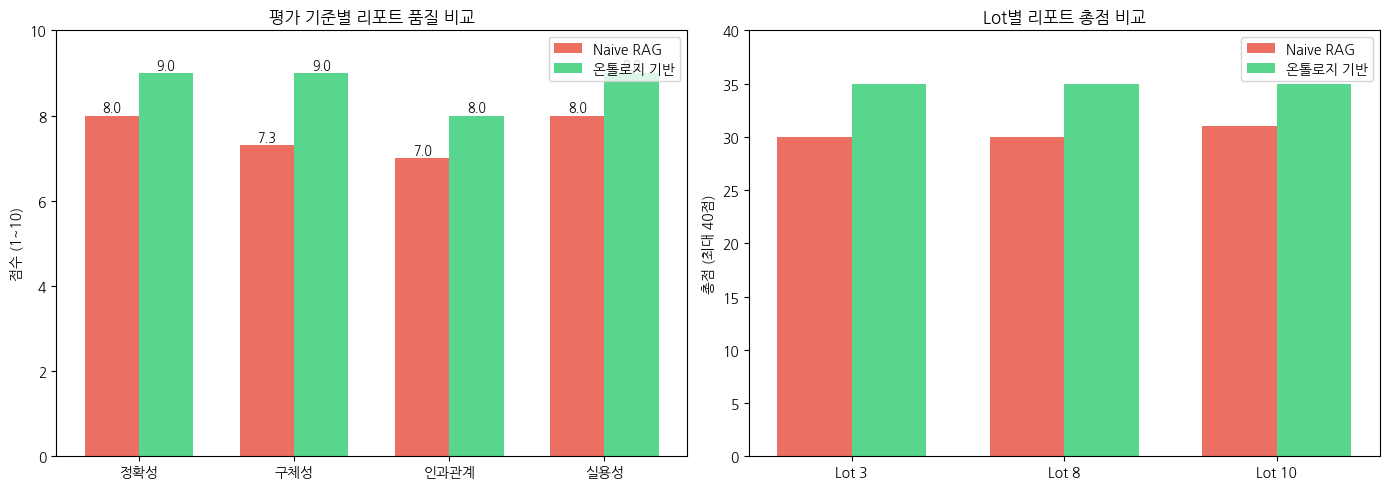


최종 결과
Naive RAG 평균 총점:      30.3 / 40점
온톨로지 기반 평균 총점:  35.0 / 40점
품질 향상:                +4.7점
향상률:                   +15.4%

자소서 한 줄:
KAMP 도금욕 실제 데이터(47,058건) 기반 LLM 온톨로지 자동 구축 후
Lot별 품질 분석 리포트 품질이 Naive RAG 대비 15.4% 향상됨을 검증.


In [36]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'

categories = ['정확성', '구체성', '인과관계', '실용성']

naive_scores = {cat: [] for cat in categories}
onto_scores = {cat: [] for cat in categories}

for lot_id in target_lots:
    result = evaluation_results[lot_id]
    for cat in categories:
        naive_scores[cat].append(result['report_A'][cat])
        onto_scores[cat].append(result['report_B'][cat])

naive_avg = {cat: round(sum(v)/len(v), 1) for cat, v in naive_scores.items()}
onto_avg = {cat: round(sum(v)/len(v), 1) for cat, v in onto_scores.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 카테고리별 점수 비교
x = range(len(categories))
width = 0.35
bars1 = axes[0].bar([i - width/2 for i in x],
                    naive_avg.values(), width,
                    label='Naive RAG', color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x],
                    onto_avg.values(), width,
                    label='온톨로지 기반', color='#2ecc71', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylim(0, 10)
axes[0].set_ylabel('점수 (1~10)')
axes[0].set_title('평가 기준별 리포트 품질 비교')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{bar.get_height():.1f}', ha='center', fontsize=9)

# 2. 총점 비교
lot_labels = [f'Lot {l}' for l in target_lots]
naive_totals = [evaluation_results[l]['report_A']['총점'] for l in target_lots]
onto_totals = [evaluation_results[l]['report_B']['총점'] for l in target_lots]

x2 = range(len(target_lots))
axes[1].bar([i - width/2 for i in x2], naive_totals, width,
           label='Naive RAG', color='#e74c3c', alpha=0.8)
axes[1].bar([i + width/2 for i in x2], onto_totals, width,
           label='온톨로지 기반', color='#2ecc71', alpha=0.8)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(lot_labels)
axes[1].set_ylim(0, 40)
axes[1].set_ylabel('총점 (최대 40점)')
axes[1].set_title('Lot별 리포트 총점 비교')
axes[1].legend()

plt.tight_layout()
plt.savefig('report_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 최종 수치
naive_total_avg = sum(naive_totals) / len(naive_totals)
onto_total_avg = sum(onto_totals) / len(onto_totals)
improvement = onto_total_avg - naive_total_avg

print("\n" + "="*60)
print("최종 결과")
print("="*60)
print(f"Naive RAG 평균 총점:      {naive_total_avg:.1f} / 40점")
print(f"온톨로지 기반 평균 총점:  {onto_total_avg:.1f} / 40점")
print(f"품질 향상:                +{improvement:.1f}점")
print(f"향상률:                   +{improvement/naive_total_avg*100:.1f}%")
print("="*60)
print(f"\n자소서 한 줄:")
print(f"KAMP 도금욕 실제 데이터(47,058건) 기반 LLM 온톨로지 자동 구축 후")
print(f"Lot별 품질 분석 리포트 품질이 Naive RAG 대비 {improvement/naive_total_avg*100:.1f}% 향상됨을 검증.")

#Lot 10 결과 해석

In [37]:
# Lot 10 상세 확인
lot10 = df[df['Lot'] == 10]
print(f"Lot 10 총 건수: {len(lot10)}")
print(f"Lot 10 불량 건수: {lot10['Result'].sum()}")
print(f"Lot 10 불량률: {lot10['Result'].mean()*100:.2f}%")
print()
print("Lot 10 센서값 통계:")
print(lot10[['pH','Temp','Current','Voltage']].describe().round(3))
print()
print("온톨로지 정상범위:")
for prop in tbox['data_properties']:
    if prop.get('normal_min') is not None:
        print(f"  {prop['name']}: {prop['normal_min']} ~ {prop['normal_max']}")
print()
print("Lot 10 위반 현황:")
print(lot_violations[10])

Lot 10 총 건수: 2139
Lot 10 불량 건수: 138
Lot 10 불량률: 6.45%

Lot 10 센서값 통계:
             pH      Temp   Current   Voltage
count  2139.000  2139.000  2139.000  2139.000
mean      2.314    24.442     3.723     3.981
std       0.512     1.905     0.457     0.604
min       1.510    18.220     1.550     1.550
25%       1.900    22.870     3.360     3.500
50%       2.290    24.470     3.730     3.990
75%       2.690    25.975     4.100     4.490
max       5.230    27.990     4.490     4.990

온톨로지 정상범위:
  pH: 1.89 ~ 2.64
  Temperature: 22.96 ~ 26.0
  Current: 3.38 ~ 4.11
  Voltage: 3.5 ~ 4.48

Lot 10 위반 현황:
{'pH': {'total': 2139, 'below_normal': 512, 'above_normal': 577, 'violation_count': 1089, 'violation_rate': np.float64(50.91), 'mean': np.float64(2.314), 'normal_min': 1.89, 'normal_max': 2.64}, 'Current': {'total': 2139, 'below_normal': 557, 'above_normal': 512, 'violation_count': 1069, 'violation_rate': np.float64(49.98), 'mean': np.float64(3.723), 'normal_min': 3.38, 'normal_max': 4.11}, 'Vol

In [38]:
print("=== Lot 10 Naive RAG 리포트 ===")
print(naive_reports[10])
print()
print("=== Lot 10 온톨로지 리포트 ===")
print(ontology_reports[10])

=== Lot 10 Naive RAG 리포트 ===
품질 분석 리포트: 도금욕 공정 Lot 10

1. 이상 징후 여부
   - 불량률: Lot 10의 총 측정 건수는 2139건이며, 이 중 불량 건수는 138건입니다. 불량률은 약 6.45%로 계산됩니다. 이는 일반적인 도금 공정의 불량률 기준과 비교하여 상대적으로 높은 수준일 수 있습니다. 따라서, 공정에 이상 징후가 있을 가능성이 있습니다.

2. 주요 원인 변수
   - pH: 평균 2.314, 표준편차 0.512
     - pH 값의 변동성이 크며, 이는 도금 품질에 직접적인 영향을 미칠 수 있습니다. 도금욕의 pH가 적절한 범위를 벗어나면 도금층의 균일성과 접착력이 저하될 수 있습니다.
   - Temp (온도): 평균 24.442, 표준편차 1.905
     - 온도의 변동성도 비교적 큰 편입니다. 도금 공정에서 온도는 화학 반응 속도에 영향을 미치므로, 온도 변화가 도금 품질에 영향을 줄 수 있습니다.
   - Current (전류): 평균 3.723, 표준편차 0.457
     - 전류의 변동성은 상대적으로 적지만, 전류 밀도가 도금 두께와 균일성에 영향을 미칠 수 있습니다.
   - Voltage (전압): 평균 3.981, 표준편차 0.604
     - 전압의 변동성도 주의가 필요합니다. 전압이 불안정하면 도금층의 두께와 품질에 영향을 줄 수 있습니다.

3. 예상되는 불량 유형
   - 도금층 불균일: pH와 온도의 변동성으로 인해 도금층의 두께가 균일하지 않을 수 있습니다.
   - 접착력 저하: pH 불균형으로 인해 도금층의 접착력이 약해질 수 있습니다.
   - 표면 결함: 전류와 전압의 변동으로 인해 표면에 결함이 발생할 수 있습니다.

4. 권고사항
   - pH 관리 강화: pH 모니터링을 강화하고, 적절한 범위 내에서 유지될 수 있도록 자동 조절 시스템을 도입하는 것을 고려합니다.
   - 온도 제어 시스템 개선: 온도 변동을 최소화하기 위해 온도 제어 시스템을 개선하고

# AI 분석 보고서 다운로드

In [39]:
# 리포트 텍스트 파일로 저장 후 다운로드
from google.colab import files

report_text = ""
report_text += "=" * 60 + "\n"
report_text += "KAMP 도금욕 공정 품질 분석 리포트 비교\n"
report_text += "=" * 60 + "\n\n"

for lot_id in target_lots:
    report_text += f"\n{'=' * 60}\n"
    report_text += f"Lot {lot_id} 분석\n"
    report_text += f"{'=' * 60}\n"

    # Lot 기본 정보
    lot_data = df[df['Lot'] == lot_id]
    report_text += f"총 건수: {len(lot_data)}건 | "
    report_text += f"불량: {lot_data['Result'].sum()}건 | "
    report_text += f"불량률: {lot_data['Result'].mean()*100:.2f}%\n\n"

    # 온톨로지 위반 현황
    v = lot_violations[lot_id]
    report_text += "[온톨로지 규칙 위반 현황]\n"
    for var, info in v.items():
        report_text += (f"  {var}: 위반 {info['violation_count']}건 "
                       f"({info['violation_rate']}%) | "
                       f"평균 {info['mean']} "
                       f"(정상: {info['normal_min']:.3f}~{info['normal_max']:.3f})\n")

    report_text += "\n--- Naive RAG 리포트 ---\n"
    report_text += naive_reports[lot_id] + "\n"

    report_text += "\n--- 온톨로지 기반 리포트 ---\n"
    report_text += ontology_reports[lot_id] + "\n"

    # LLM Judge 평가 결과
    result = evaluation_results[lot_id]
    report_text += "\n[LLM Judge 평가]\n"
    report_text += f"  Naive RAG 총점: {result['report_A']['총점']}/40\n"
    report_text += f"  온톨로지 기반 총점: {result['report_B']['총점']}/40\n"
    report_text += f"  우수 리포트: {result['우수한_리포트']}\n"
    report_text += f"  이유: {result['이유']}\n"

# 파일 저장 및 다운로드
with open('quality_analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

files.download('quality_analysis_report.txt')
print("리포트 다운로드 완료")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

리포트 다운로드 완료


In [40]:
import json
from google.colab import files

# 1. CQ 저장
cq_output = {
    "title": "KAMP 도금욕 공정 온톨로지 Competency Questions",
    "source": "KAMP 품질 이상탐지·진단(도금욕) AI 데이터셋 가이드북",
    "method": "Kommineni et al.(2024) 방법론 기반 LLM 자동 생성",
    "model": "gpt-4o",
    "competency_questions": cqs
}

with open('01_competency_questions.json', 'w', encoding='utf-8') as f:
    json.dump(cq_output, f, ensure_ascii=False, indent=2)

# 2. TBox 저장
tbox_output = {
    "title": "KAMP 도금욕 공정 온톨로지 TBox",
    "method": "Kommineni et al.(2024) + Zengeya et al.(2026) 방법론",
    "normal_range_method": "데이터 25%~75% 사분위수 (human-in-the-loop 수정)",
    "tbox": tbox
}

with open('02_tbox.json', 'w', encoding='utf-8') as f:
    json.dump(tbox_output, f, ensure_ascii=False, indent=2)

# 3. ABox 저장 (Lot별 위반 현황 = 인스턴스 데이터)
abox_output = {
    "title": "KAMP 도금욕 공정 온톨로지 ABox",
    "description": "Lot별 온톨로지 정상범위 위반 현황 (인스턴스 레벨 데이터)",
    "total_lots": df['Lot'].nunique(),
    "total_samples": len(df),
    "abox_instances": {}
}

for lot_id in sorted(df['Lot'].unique()):
    lot_data = df[df['Lot'] == lot_id]
    abox_output["abox_instances"][f"Lot_{lot_id}"] = {
        "lot_id": int(lot_id),
        "total_count": int(len(lot_data)),
        "defect_count": int(lot_data['Result'].sum()),
        "defect_rate": round(float(lot_data['Result'].mean() * 100), 2),
        "sensor_stats": {
            var: {
                "mean": round(float(lot_data[var].mean()), 3),
                "std": round(float(lot_data[var].std()), 3),
                "min": round(float(lot_data[var].min()), 3),
                "max": round(float(lot_data[var].max()), 3)
            }
            for var in ['pH', 'Temp', 'Current', 'Voltage']
        },
        "ontology_violations": lot_violations[lot_id]
    }

with open('03_abox.json', 'w', encoding='utf-8') as f:
    json.dump(abox_output, f, ensure_ascii=False, indent=2, default=str)

# 4. RDF 온톨로지 파일도 함께
# (이미 생성된 plating_ontology.ttl 포함)

# 다운로드
files.download('01_competency_questions.json')
files.download('02_tbox.json')
files.download('03_abox.json')

print("다운로드 완료:")
print("  01_competency_questions.json - 자동 생성된 CQ 10개")
print("  02_tbox.json - 온톨로지 TBox (클래스, 관계, 정상범위, 인과규칙)")
print("  03_abox.json - 온톨로지 ABox (22개 Lot 인스턴스 데이터)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: plating_ontology.ttl

In [41]:
from rdflib import Graph, Namespace, URIRef, Literal, RDF, RDFS, OWL, XSD

def build_rdf_ontology(tbox):
    g = Graph()
    PLATING = Namespace("http://kamp.kaist.ac.kr/plating#")
    g.bind("plating", PLATING)
    g.bind("owl", OWL)

    for cls in tbox['classes']:
        class_uri = PLATING[cls['name']]
        g.add((class_uri, RDF.type, OWL.Class))
        g.add((class_uri, RDFS.label, Literal(cls['korean'], lang="ko")))

    for prop in tbox['object_properties']:
        prop_uri = PLATING[prop['name']]
        g.add((prop_uri, RDF.type, OWL.ObjectProperty))
        g.add((prop_uri, RDFS.domain, PLATING[prop['domain']]))
        g.add((prop_uri, RDFS.range, PLATING[prop['range']]))

    for prop in tbox['data_properties']:
        prop_uri = PLATING[prop['name']]
        g.add((prop_uri, RDF.type, OWL.DatatypeProperty))
        if prop.get('normal_min') is not None:
            g.add((prop_uri, PLATING['normalMin'],
                   Literal(prop['normal_min'], datatype=XSD.float)))
            g.add((prop_uri, PLATING['normalMax'],
                   Literal(prop['normal_max'], datatype=XSD.float)))

    for i, rule in enumerate(tbox['causal_rules']):
        rule_uri = PLATING[f"CausalRule_{i}"]
        g.add((rule_uri, RDF.type, PLATING['CausalRule']))
        g.add((rule_uri, PLATING['hasVariable'],
               Literal(rule['variable'], lang="ko")))
        g.add((rule_uri, PLATING['hasCondition'],
               Literal(rule['condition'], lang="ko")))
        for defect in rule['defect_types']:
            g.add((rule_uri, PLATING['causesDefect'],
                   Literal(defect, lang="ko")))

    return g

rdf_graph = build_rdf_ontology(tbox)
rdf_graph.serialize("plating_ontology.ttl", format="turtle")
print(f"RDF 온톨로지 저장 완료: {len(rdf_graph)}개 트리플")

from google.colab import files
files.download('plating_ontology.ttl')

RDF 온톨로지 저장 완료: 44개 트리플


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
from rdflib import Graph

g = Graph()
g.parse('plating_ontology.ttl', format='turtle')

print(f"총 트리플 수: {len(g)}개\n")
for s, p, o in sorted(g):
    print(f"{s.split('#')[-1]:30} | {p.split('#')[-1]:20} | {o.split('#')[-1] if '#' in str(o) else o}")

총 트리플 수: 44개

CausalRule_0                   | causesDefect         | AdhesionLoss
CausalRule_0                   | causesDefect         | Corrosion
CausalRule_0                   | causesDefect         | DurabilityLoss
CausalRule_0                   | hasCondition         | pH < 1.51 or pH > 5.48
CausalRule_0                   | hasVariable          | pH
CausalRule_0                   | type                 | CausalRule
CausalRule_1                   | causesDefect         | Corrosion
CausalRule_1                   | causesDefect         | EfficiencyLoss
CausalRule_1                   | hasCondition         | Temperature < 17.02 or Temperature > 27.99
CausalRule_1                   | hasVariable          | Temperature
CausalRule_1                   | type                 | CausalRule
CausalRule_2                   | causesDefect         | EfficiencyLoss
CausalRule_2                   | causesDefect         | SurfaceStain
CausalRule_2                   | hasCondition         | Current 

In [43]:
# ttl 파일 내용 출력
with open('plating_ontology.ttl', 'r', encoding='utf-8') as f:
    content = f.read()
print(content)

@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix plating: <http://kamp.kaist.ac.kr/plating#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

plating:CausalRule_0 a plating:CausalRule ;
    plating:causesDefect "AdhesionLoss"@ko,
        "Corrosion"@ko,
        "DurabilityLoss"@ko ;
    plating:hasCondition "pH < 1.51 or pH > 5.48"@ko ;
    plating:hasVariable "pH"@ko .

plating:CausalRule_1 a plating:CausalRule ;
    plating:causesDefect "Corrosion"@ko,
        "EfficiencyLoss"@ko ;
    plating:hasCondition "Temperature < 17.02 or Temperature > 27.99"@ko ;
    plating:hasVariable "Temperature"@ko .

plating:CausalRule_2 a plating:CausalRule ;
    plating:causesDefect "EfficiencyLoss"@ko,
        "SurfaceStain"@ko ;
    plating:hasCondition "Current < 1.52 or Current > 4.49"@ko ;
    plating:hasVariable "Current"@ko .

plating:CausalRule_3 a plating:CausalRule ;
    plating:causesDefect "CurrentDensityIssue"@ko ;
    p